# Cross-Domain AI Image Detection — Training Notebook
**General images. No face cropping. No face datasets.**

Trains MobileNetV3 across multiple real/fake domains. Saves to `/kaggle/working/output/mobilenetv3_cross_domain.pth`.

### Datasets to attach in Kaggle:
| Dataset | Kaggle slug | Purpose |
|---|---|---|
| Nano Banana | `ahnuf05/ai-imagewith-nano-banana-2-0-vs-real-image` | AI art vs real photos |
| CIFAKE | `birdy654/cifake-real-and-ai-generated-synthetic-images` | SDXL vs CIFAR-10 objects |
| CrossDomain | `rahulshetty1020/crossdomain` | Your ChatGPT images + real photos |
| **Places365** | `nick-s-workspace/places365-standard` | ✅ NEW — 1.8M real indoor/outdoor scenes |
| **Artifact** | `awsaf49/artifact-dataset` | ✅ NEW — AI-generated scenes (DALL-E, SD, Midjourney) |


In [1]:
# Cell 1 — Imports
import os, io, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# Cell 2 — Configuration (Kaggle paths only)
SUPPORTED = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

# ── REAL image sources ────────────────────────────────────────────────────────
REAL_DIRS = [
    # Nano Banana real photos
    '/kaggle/input/datasets/ahnuf05/ai-imagewith-nano-banana-2-0-vs-real-image/dataset/train/real',
    # CIFAKE real (CIFAR-10 objects)
    '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL',
    # Your CrossDomain real photos (ChatGPT test set)
    '/kaggle/input/datasets/rahulshetty1020/crossdomain/Real',
    # Places365 — real indoor/outdoor scene photos
    # Attach: nickj26/places-2-mit-dataset
    '/kaggle/input/datasets/nickj26/places2-mit-dataset/train_256_places365standard/data_256',  # Places-2_MIT_Dataset by Nikhil Joson
]

# ── FAKE image sources ────────────────────────────────────────────────────────
FAKE_DIRS = [
    # Nano Banana AI art
    '/kaggle/input/datasets/ahnuf05/ai-imagewith-nano-banana-2-0-vs-real-image/dataset/train/fake',
    # CIFAKE fake (SDXL-generated CIFAR-10 objects)
    '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE',
    # Your CrossDomain fake photos (ChatGPT generated)
    '/kaggle/input/datasets/rahulshetty1020/crossdomain/Fake',
    # ARTIFACT — AI-generated scenes from multiple generators (DALL-E, SD, Midjourney)
    # Attach: awsaf49/artifact-dataset
    '/kaggle/input/datasets/awsaf49/artifact-dataset',  # root contains subfolders per GAN type (afhq, big_gan, ddpm, etc.)
]

OUTPUT_DIR      = '/kaggle/working/output'
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'mobilenetv3_cross_domain.pth')
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS_STAGE1 = 3
EPOCHS_STAGE2 = 7
LR_STAGE1     = 3e-4
LR_STAGE2     = 1e-5
VAL_SPLIT     = 0.15
CLASSES       = ['Real', 'Fake']

# Cap per directory — Places365 has 1.8M images so we cap to keep training manageable
# Small datasets (CrossDomain = 10 images) will just use all they have
MAX_PER_DIR       = 5000   # cap for large datasets
MAX_PLACES365     = 10000  # higher cap for Places365 (more diversity needed)
MAX_ARTIFACT      = 8000   # cap for artifact fake scenes

print(f'Model will save to: {MODEL_SAVE_PATH}')
print(f'REAL sources: {len(REAL_DIRS)}  FAKE sources: {len(FAKE_DIRS)}')


Model will save to: /kaggle/working/output/mobilenetv3_cross_domain.pth
REAL sources: 4  FAKE sources: 4


In [3]:
# Cell 2b — Verify all dataset paths (run this first to check what's available)
import os

print('=== Checking all configured paths ===')
all_dirs = REAL_DIRS + FAKE_DIRS
for d in all_dirs:
    p = Path(d)
    if p.exists():
        count = sum(1 for f in p.rglob('*') if f.suffix.lower() in SUPPORTED and f.is_file())
        print(f'  ✓ EXISTS  : {d}  ({count:,} images)')
    else:
        print(f'  ✗ MISSING : {d}')

print()
print('=== Datasets to attach in Kaggle if MISSING above ===')
print('  Places365 real scenes  → nick-s-workspace/places365-standard')
print('  Artifact AI fakes      → awsaf49/artifact-dataset')


=== Checking all configured paths ===
  ✓ EXISTS  : /kaggle/input/datasets/ahnuf05/ai-imagewith-nano-banana-2-0-vs-real-image/dataset/train/real  (16,000 images)
  ✓ EXISTS  : /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL  (50,000 images)
  ✓ EXISTS  : /kaggle/input/datasets/rahulshetty1020/crossdomain/Real  (10 images)
  ✓ EXISTS  : /kaggle/input/datasets/nickj26/places2-mit-dataset/train_256_places365standard/data_256  (1,803,460 images)
  ✓ EXISTS  : /kaggle/input/datasets/ahnuf05/ai-imagewith-nano-banana-2-0-vs-real-image/dataset/train/fake  (15,999 images)
  ✓ EXISTS  : /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE  (50,000 images)
  ✓ EXISTS  : /kaggle/input/datasets/rahulshetty1020/crossdomain/Fake  (6 images)
  ✓ EXISTS  : /kaggle/input/datasets/awsaf49/artifact-dataset  (2,496,738 images)

=== Datasets to attach in Kaggle if MISSING above ===
  Places365 real scenes  → nick-s-workspace/places

In [4]:
# Cell 3 — Collect image paths
def collect(dirs, label, default_cap=5000, dir_caps=None):
    """
    dir_caps: dict mapping path substring → custom cap
    e.g. {'places365': 10000, 'artifact': 8000}
    """
    dir_caps = dir_caps or {}
    records = []
    for d in dirs:
        p = Path(d)
        if not p.exists():
            print(f'  [WARN] Not found: {d}'); continue
        files = [f for f in p.rglob('*') if f.suffix.lower() in SUPPORTED]
        random.shuffle(files)
        # apply custom cap if path matches
        cap = default_cap
        for key, val in dir_caps.items():
            if key in str(d):
                cap = val; break
        files = files[:cap]
        for f in files:
            records.append({'filepath': str(f), 'label': label,
                            'label_name': CLASSES[label], 'domain': p.name})
        print(f'  {CLASSES[label]} | {p.name}: {len(files)} images')
    return records

CAPS = {'places365': MAX_PLACES365, 'artifact': MAX_ARTIFACT}

print('Real images:')
real_r = collect(REAL_DIRS, 0, MAX_PER_DIR, CAPS)
print(f'  → Total real: {len(real_r)}')

print('\nFake images:')
fake_r = collect(FAKE_DIRS, 1, MAX_PER_DIR, CAPS)
print(f'  → Total fake: {len(fake_r)}')

df = pd.DataFrame(real_r + fake_r).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'\nDataset total: {len(df)}')
print(df.groupby(['domain', 'label_name']).size().to_string())


Real images:
  Real | real: 5000 images
  Real | REAL: 5000 images
  Real | Real: 10 images
  Real | data_256: 10000 images
  → Total real: 20010

Fake images:
  Fake | fake: 5000 images
  Fake | FAKE: 5000 images
  Fake | Fake: 6 images
  Fake | artifact-dataset: 8000 images
  → Total fake: 18006

Dataset total: 38016
domain            label_name
FAKE              Fake           5000
Fake              Fake              6
REAL              Real           5000
Real              Real             10
artifact-dataset  Fake           8000
data_256          Real          10000
fake              Fake           5000
real              Real           5000


In [5]:
# Cell 4 — Transforms
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1),
])
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print('Transforms ready.')

Transforms ready.


In [6]:
# Cell 5 — Dataset & DataLoader
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df['filepath'].values
        self.labels = df['label'].values
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_df, val_df = train_test_split(df, test_size=VAL_SPLIT, random_state=SEED, stratify=df['label'])
print(f'Train: {len(train_df)}  Val: {len(val_df)}')

labels = train_df['label'].values; counts = np.bincount(labels)
sampler = WeightedRandomSampler(1.0 / counts[labels], len(labels), replacement=True)

train_ds = ImageDataset(train_df, TRAIN_TRANSFORM)
val_ds   = ImageDataset(val_df,   VAL_TRANSFORM)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)
print(f'Batches — Train: {len(train_loader)}  Val: {len(val_loader)}')

Train: 32313  Val: 5703
Batches — Train: 1010  Val: 179


In [7]:
# Cell 6 — Build MobileNetV3-Large
# NOTE: Requires internet ON in Kaggle settings (right sidebar → Settings → Internet → On)
def build_model(freeze_backbone=True):
    try:
        m = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
        print('✓ Loaded pretrained ImageNet weights')
    except Exception as e:
        print(f'⚠ Could not download pretrained weights ({e})')
        print('  → Enable internet: Kaggle sidebar → Settings → Internet → On')
        print('  → Falling back to random init (accuracy will be lower)')
        m = mobilenet_v3_large(weights=None)
    if freeze_backbone:
        for p in m.features.parameters(): p.requires_grad = False
    in_f = m.classifier[0].in_features
    m.classifier = nn.Sequential(
        nn.Linear(in_f, 1280), nn.Hardswish(), nn.Dropout(p=0.2), nn.Linear(1280, 2)
    )
    return m.to(DEVICE)

model = build_model(freeze_backbone=True)
print(f'Trainable params (Stage 1): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 169MB/s]


✓ Loaded pretrained ImageNet weights
Trainable params (Stage 1): 1,232,642


In [8]:
# Cell 7 — Training helpers
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train(); loss_sum = correct = total = 0
    for imgs, lbls in tqdm(loader, leave=False, desc='train'):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE); optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=DEVICE.type=='cuda'):
            out = model(imgs); loss = criterion(out, lbls)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        loss_sum += loss.item()*imgs.size(0)
        correct  += (out.argmax(1)==lbls).sum().item(); total += imgs.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval(); loss_sum = correct = total = 0
    for imgs, lbls in tqdm(loader, leave=False, desc='val'):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = model(imgs); loss = criterion(out, lbls)
        loss_sum += loss.item()*imgs.size(0)
        correct  += (out.argmax(1)==lbls).sum().item(); total += imgs.size(0)
    return loss_sum/total, correct/total

def save_checkpoint(model, optimizer, epoch, val_acc):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state': optimizer.state_dict(), 'val_acc': val_acc,
                'model_name': 'mobilenetv3_cross_domain', 'classes': CLASSES, 'img_size': IMG_SIZE},
               MODEL_SAVE_PATH)
    print(f'  ✓ Saved → {MODEL_SAVE_PATH}  (val_acc={val_acc:.4f})')
print('Helpers ready.')

Helpers ready.


In [9]:
# Cell 8 — Stage 1: Frozen backbone
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_STAGE1, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_STAGE1)
scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type=='cuda')
best_val_acc = 0.0; history = []

print(f'=== Stage 1: {EPOCHS_STAGE1} epochs | LR={LR_STAGE1} | Backbone FROZEN ===')
for epoch in range(1, EPOCHS_STAGE1+1):
    t0 = time.time()
    tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl, va = val_epoch(model, val_loader, criterion); scheduler.step()
    print(f'  Ep {epoch}/{EPOCHS_STAGE1}  tr_loss={tl:.4f} tr_acc={ta:.4f}  vl_loss={vl:.4f} vl_acc={va:.4f}  ({time.time()-t0:.0f}s)')
    history.append({'stage': 1, 'epoch': epoch, 'tr_acc': ta, 'vl_acc': va})
    if va > best_val_acc: best_val_acc = va; save_checkpoint(model, optimizer, epoch, va)
print(f'Stage 1 done. Best val_acc: {best_val_acc:.4f}')

=== Stage 1: 3 epochs | LR=0.0003 | Backbone FROZEN ===


/tmp/ipykernel_107/3453709489.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type=='cuda')


train:   0%|          | 0/1010 [00:00<?, ?it/s]

/tmp/ipykernel_107/1954888756.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type=='cuda'):


val:   0%|          | 0/179 [00:00<?, ?it/s]

...

val:   0%|          | 0/179 [00:00<?, ?it/s]

  Ep 2/3  tr_loss=0.4513 tr_acc=0.8090  vl_loss=0.4247 vl_acc=0.8264  (551s)
  ✓ Saved → /kaggle/working/output/mobilenetv3_cross_domain.pth  (val_acc=0.8264)


train:   0%|          | 0/1010 [00:00<?, ?it/s]

val:   0%|          | 0/179 [00:00<?, ?it/s]

  Ep 3/3  tr_loss=0.4251 tr_acc=0.8292  vl_loss=0.4268 vl_acc=0.8282  (538s)
  ✓ Saved → /kaggle/working/output/mobilenetv3_cross_domain.pth  (val_acc=0.8282)
Stage 1 done. Best val_acc: 0.8282


In [10]:
# Cell 9 — Stage 2: Partial unfreeze (last 25% of backbone)
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
blocks = list(model.features.children()); unfreeze_from = int(len(blocks)*0.75)
for i, block in enumerate(blocks):
    for p in block.parameters(): p.requires_grad = (i >= unfreeze_from)
print(f'Unfreezing blocks {unfreeze_from}-{len(blocks)-1}')
print(f'Trainable params (Stage 2): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

optimizer2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_STAGE2, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS_STAGE2)

print(f'\n=== Stage 2: {EPOCHS_STAGE2} epochs | LR={LR_STAGE2} | Backbone PARTIAL ===')
for epoch in range(1, EPOCHS_STAGE2+1):
    t0 = time.time()
    tl, ta = train_epoch(model, train_loader, optimizer2, criterion, scaler)
    vl, va = val_epoch(model, val_loader, criterion); scheduler2.step()
    print(f'  Ep {epoch}/{EPOCHS_STAGE2}  tr_loss={tl:.4f} tr_acc={ta:.4f}  vl_loss={vl:.4f} vl_acc={va:.4f}  ({time.time()-t0:.0f}s)')
    history.append({'stage': 2, 'epoch': epoch, 'tr_acc': ta, 'vl_acc': va})
    if va > best_val_acc: best_val_acc = va; save_checkpoint(model, optimizer2, epoch, va)
print(f'\nTraining complete. Best val_acc: {best_val_acc:.4f}')
print(f'Model saved: {MODEL_SAVE_PATH}')

Unfreezing blocks 12-16
Trainable params (Stage 2): 3,798,226

=== Stage 2: 7 epochs | LR=1e-05 | Backbone PARTIAL ===


train:   0%|          | 0/1010 [00:00<?, ?it/s]

/tmp/ipykernel_107/1954888756.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type=='cuda'):


val:   0%|          | 0/179 [00:00<?, ?it/s]

  Ep 1/7  tr_loss=0.3990 tr_acc=0.8463  vl_loss=0.3771 vl_acc=0.8595  (546s)
  ✓ Saved → /kaggle/working/output/mobilenetv3_cross_domain.pth  (val_acc=0.8595)


...

val:   0%|          | 0/179 [00:00<?, ?it/s]

  Ep 6/7  tr_loss=0.3112 tr_acc=0.8999  vl_loss=0.3128 vl_acc=0.9018  (529s)
  ✓ Saved → /kaggle/working/output/mobilenetv3_cross_domain.pth  (val_acc=0.9018)


train:   0%|          | 0/1010 [00:00<?, ?it/s]

val:   0%|          | 0/179 [00:00<?, ?it/s]

  Ep 7/7  tr_loss=0.3055 tr_acc=0.9037  vl_loss=0.3113 vl_acc=0.9030  (543s)
  ✓ Saved → /kaggle/working/output/mobilenetv3_cross_domain.pth  (val_acc=0.9030)

Training complete. Best val_acc: 0.9030
Model saved: /kaggle/working/output/mobilenetv3_cross_domain.pth


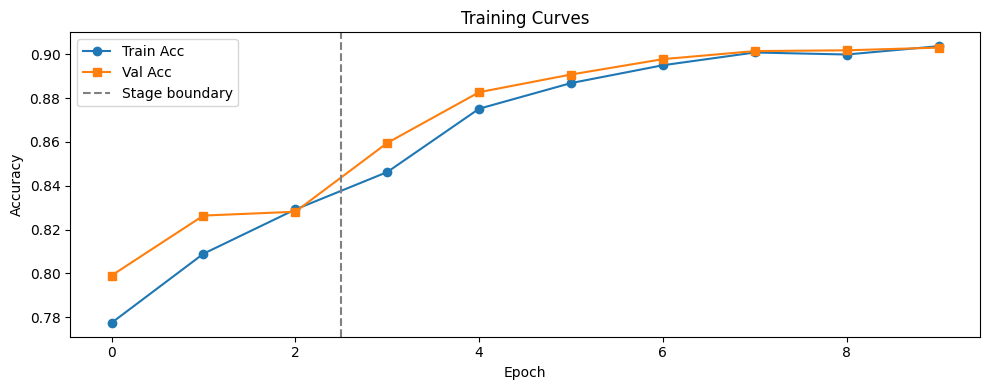

In [11]:
# Cell 10 — Training curves
hist = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist['tr_acc'].values, marker='o', label='Train Acc')
ax.plot(hist['vl_acc'].values, marker='s', label='Val Acc')
ax.axvline(EPOCHS_STAGE1 - 0.5, color='gray', ls='--', label='Stage boundary')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training Curves'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [12]:
# Cell 11 — Per-domain validation accuracy
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict']); model.eval()
rows = []
for domain, grp in val_df.groupby('domain'):
    ds = ImageDataset(grp, VAL_TRANSFORM)
    dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    preds, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in dl:
            preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            labels_list.extend(lbls.numpy())
    acc = accuracy_score(labels_list, preds)*100
    rows.append({'Domain': domain, 'Class': CLASSES[grp['label'].iloc[0]], 'N': len(grp), 'Accuracy (%)': round(acc,1)})
dr = pd.DataFrame(rows); print(dr.to_string(index=False))
dr.to_csv(os.path.join(OUTPUT_DIR, 'domain_accuracy.csv'), index=False)

          Domain Class    N  Accuracy (%)
            FAKE  Fake  728          96.3
            Fake  Fake    2         100.0
            REAL  Real  734          85.3
            Real  Real    1           0.0
artifact-dataset  Fake 1251          79.4
        data_256  Real 1521          93.3
            fake  Fake  720          97.2
            real  Real  746          95.0


              precision    recall  f1-score   support

        Real       0.90      0.92      0.91      3002
        Fake       0.91      0.89      0.90      2701

    accuracy                           0.90      5703
   macro avg       0.90      0.90      0.90      5703
weighted avg       0.90      0.90      0.90      5703



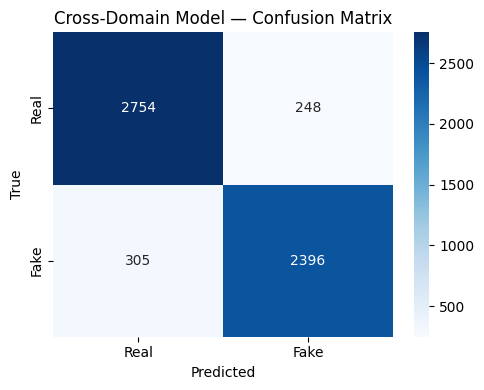


✓ Done. Model: /kaggle/working/output/mobilenetv3_cross_domain.pth


In [13]:
# Cell 12 — Confusion matrix + classification report
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        all_preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())
print(classification_report(all_labels, all_preds, target_names=CLASSES))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Cross-Domain Model — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print(f'\n✓ Done. Model: {MODEL_SAVE_PATH}')

---
## 🧪 Test the Model — Upload Your Own Image
Run the cell below after training. Upload any image to get a Real / Fake prediction.

In [14]:
# Cell 13 — Interactive Image Upload Tester
import ipywidgets as widgets
from IPython.display import display, clear_output

def load_trained_model():
    m = mobilenet_v3_large(weights=None)
    in_f = m.classifier[0].in_features
    m.classifier = nn.Sequential(nn.Linear(in_f, 1280), nn.Hardswish(), nn.Dropout(p=0.2), nn.Linear(1280, 2))
    ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
    state = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    m.load_state_dict(state)
    return m.to(DEVICE).eval()

try:
    test_model = load_trained_model()
    print(f'✓ Model loaded from {MODEL_SAVE_PATH}')
except Exception as e:
    print(f'⚠ Could not load model: {e}')
    print('  Run the training cells first.')
    test_model = None

upload_btn  = widgets.FileUpload(accept='image/*', multiple=True,
                                  description='Upload Images', button_style='info',
                                  layout=widgets.Layout(width='220px'))
clear_btn   = widgets.Button(description='Clear', button_style='warning',
                              layout=widgets.Layout(width='80px'))
status_lbl  = widgets.Label(value='Upload one or more images to test the model.')
output_area = widgets.Output()
FAKE_THRESHOLD = 65.0

def predict_and_show(img, filename):
    x = VAL_TRANSFORM(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(test_model(x), dim=1)[0].cpu()
    real_pct = probs[0].item()*100; fake_pct = probs[1].item()*100
    pred = 'Fake' if fake_pct >= FAKE_THRESHOLD else 'Real'
    conf = fake_pct if pred == 'Fake' else real_pct

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'width_ratios': [1, 1.2]})
    fig.patch.set_facecolor('#0d1117')
    thumb = img.copy(); thumb.thumbnail((400, 400))
    axes[0].imshow(thumb)
    axes[0].set_title(filename[:35], fontsize=8, color='white', pad=4)
    axes[0].axis('off'); axes[0].set_facecolor('#0d1117')
    ax = axes[1]; ax.set_facecolor('#0d1117')
    ax.set_xlim(0, 115); ax.set_ylim(-0.5, 1.5)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Fake', 'Real'], color='white', fontsize=12)
    ax.tick_params(axis='x', colors='white')
    for spine in ax.spines.values(): spine.set_color('#444')
    ax.barh(1, real_pct, color='#2196F3', height=0.4, alpha=0.85)
    ax.barh(0, fake_pct, color='#F44336', height=0.4, alpha=0.85)
    ax.text(real_pct+1, 1, f'{real_pct:.1f}%', va='center', color='white', fontsize=11, fontweight='bold')
    ax.text(fake_pct+1, 0, f'{fake_pct:.1f}%', va='center', color='white', fontsize=11, fontweight='bold')
    verdict_color = '#F44336' if pred == 'Fake' else '#2196F3'
    ax.set_title(f"{'\U0001f916 AI GENERATED' if pred=='Fake' else '\U0001f4f7 REAL'}\n{conf:.1f}% confident",
                 fontsize=14, fontweight='bold', color=verdict_color, pad=10)
    ax.set_xlabel('Confidence (%)', color='white', fontsize=9)
    plt.tight_layout()
    return fig, pred, real_pct, fake_pct

def on_upload(change):
    if test_model is None:
        status_lbl.value = '⚠ Model not loaded.'; return
    with output_area:
        clear_output(wait=True)
        uploaded = upload_btn.value
        if not uploaded: return
        items = uploaded.items() if hasattr(uploaded, 'items') else enumerate(uploaded)
        for name, info in items:
            try:
                content = info['content'] if isinstance(info, dict) else info.content
                img = Image.open(io.BytesIO(bytes(content))).convert('RGB')
                fname = name if isinstance(name, str) else info.get('name', f'image_{name}')
                fig, pred, real_pct, fake_pct = predict_and_show(img, fname)
                plt.show()
                print(f'  {pred}  |  Real: {real_pct:.1f}%  Fake: {fake_pct:.1f}%\n')
            except Exception as e:
                print(f'  Error: {e}')
    status_lbl.value = f'✓ {len(upload_btn.value)} image(s) tested.'

def on_clear(_):
    with output_area: clear_output()
    status_lbl.value = 'Upload one or more images to test the model.'

upload_btn.observe(on_upload, names='value')
clear_btn.on_click(on_clear)
display(widgets.VBox([
    widgets.HTML("<h3 style='color:#58a6ff'>\U0001f50d Test Your Cross-Domain Model</h3>"
                 "<p style='color:#8b949e'>JPG, PNG, WEBP supported. Upload multiple at once.</p>"),
    widgets.HBox([upload_btn, clear_btn]), status_lbl, output_area
]))

✓ Model loaded from /kaggle/working/output/mobilenetv3_cross_domain.pth


## After Training
1. **Kaggle → Output tab** → download `output/mobilenetv3_cross_domain.pth`
2. Place at `C:\Users\royvi\Downloads\final deepfake\mobilenetv3_cross_domain.pth`
3. Restart backend — loads automatically

In [15]:
# ============================================================
# GPU Latency + VRAM Benchmark for mobilenetv3_best.pth
# Paste this as a new cell in final-mobilenet (1).ipynb on Kaggle
# (run it AFTER the model has been trained/loaded, T4 GPU on)
# ============================================================

import time
import csv

import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "-", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU")

# ------------------------------------------------------------
# Rebuild the exact architecture and load the trained checkpoint
# (same as Cell 5/8 in this notebook)
# ------------------------------------------------------------
model = mobilenet_v3_large(weights=None)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 2)

checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()
print(f"Loaded checkpoint from {MODEL_SAVE_PATH}")

# ------------------------------------------------------------
# Build 100 single-image batches from the existing test_loader
# (falls back to random tensors if test_loader isn't in scope)
# ------------------------------------------------------------
bench_inputs = []
try:
    for images, _ in test_loader:
        for i in range(images.size(0)):
            bench_inputs.append(images[i:i+1].to(DEVICE))
            if len(bench_inputs) >= 100:
                break
        if len(bench_inputs) >= 100:
            break
    print(f"Using {len(bench_inputs)} real test images for the benchmark.")
except NameError:
    print("test_loader not in scope - using random tensors instead.")
    bench_inputs = [torch.randn(1, 3, 224, 224).to(DEVICE) for _ in range(100)]

# ------------------------------------------------------------
# Warmup (5 runs, discarded - excludes CUDA context/kernel
# compilation overhead from the timed results)
# ------------------------------------------------------------
with torch.no_grad():
    for t in bench_inputs[:5]:
        model(t)
    torch.cuda.synchronize()

# ------------------------------------------------------------
# Reset peak-memory tracking AFTER warmup, so it only reflects
# steady-state inference memory, not one-time allocator setup
# ------------------------------------------------------------
torch.cuda.reset_peak_memory_stats(DEVICE)

# ------------------------------------------------------------
# Timed inference loop - single-image batches, matching the
# real /predict serving pattern (one image per request)
# ------------------------------------------------------------
times_ms = []
with torch.no_grad():
    for t in bench_inputs:
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(t)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000)

import statistics
mean_ms = statistics.mean(times_ms)
std_ms = statistics.stdev(times_ms)
min_ms = min(times_ms)
max_ms = max(times_ms)
throughput = 1000.0 / mean_ms

peak_vram_mib = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)

print("=" * 60)
print("GPU Latency Benchmark Results")
print("=" * 60)
print(f"N images         : {len(bench_inputs)}")
print(f"Mean latency      : {mean_ms:.3f} ms")
print(f"Std latency       : {std_ms:.3f} ms")
print(f"Min latency       : {min_ms:.3f} ms")
print(f"Max latency       : {max_ms:.3f} ms")
print(f"Throughput        : {throughput:.2f} images/sec")
print(f"Peak VRAM (steady-state inference): {peak_vram_mib:.2f} MiB")

# ------------------------------------------------------------
# Save to CSV - download this from the Kaggle Output tab and
# hand it back for Sections 4.4 / 9.2 / 9.3
# ------------------------------------------------------------
with open("/kaggle/working/gpu_latency_benchmark.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Device", "N_images", "mean_ms", "std_ms", "min_ms", "max_ms", "throughput_img_per_sec", "peak_vram_mib"])
    w.writerow(["GPU (Tesla T4)", len(bench_inputs), f"{mean_ms:.3f}", f"{std_ms:.3f}", f"{min_ms:.3f}", f"{max_ms:.3f}", f"{throughput:.2f}", f"{peak_vram_mib:.2f}"])
print("\nSaved: /kaggle/working/gpu_latency_benchmark.csv")

Device: cuda - Tesla T4
Loaded checkpoint from /kaggle/working/output/mobilenetv3_cross_domain.pth
test_loader not in scope - using random tensors instead.
GPU Latency Benchmark Results
N images         : 100
Mean latency      : 6.452 ms
Std latency       : 1.173 ms
Min latency       : 5.778 ms
Max latency       : 11.687 ms
Throughput        : 154.98 images/sec
Peak VRAM (steady-state inference): 274.24 MiB

Saved: /kaggle/working/gpu_latency_benchmark.csv


In [16]:
# ============================================================
# Real ROC-AUC + PR Curve for mobilenetv3_best.pth, on the
# ACTUAL 2,401-image held-out test set.
#
# Paste this as a NEW cell in final-mobilenet (1).ipynb, directly
# AFTER Cell 8 (Final Evaluation) has already run successfully -
# it reuses `model`, `test_loader`, `DEVICE` from that cell, so
# there's nothing new to load or configure.
#
# No CUDA-specific calls (no .synchronize(), no memory stats) -
# this only needs whatever device Cell 8 already ran on.
# ============================================================

import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

model.eval()

all_labels = []
all_probs_fake = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        with autocast():
            outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # P(Fake)
        all_labels.extend(labels.numpy())
        all_probs_fake.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs_fake = np.array(all_probs_fake)
print(f"Collected {len(all_labels)} predictions from test_loader.")

# ------------------------------------------------------------
# ROC curve + AUC
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs_fake)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC (real held-out test set): {roc_auc:.4f}")

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — mobilenetv3_best.pth (real held-out test set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve_real_testset.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Precision-Recall curve + Average Precision
# ------------------------------------------------------------
precision, recall, _ = precision_recall_curve(all_labels, all_probs_fake)
ap = average_precision_score(all_labels, all_probs_fake)
print(f"Average Precision (PR-AUC): {ap:.4f}")

plt.figure(figsize=(5.5, 5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — mobilenetv3_best.pth (real held-out test set)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("/kaggle/working/pr_curve_real_testset.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Save results CSV
# ------------------------------------------------------------
import csv
with open("/kaggle/working/roc_auc_real_testset.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Metric", "Value"])
    w.writerow(["N_test_images", len(all_labels)])
    w.writerow(["ROC-AUC", f"{roc_auc:.4f}"])
    w.writerow(["Average_Precision_PR_AUC", f"{ap:.4f}"])
print("\nSaved: roc_curve_real_testset.png, pr_curve_real_testset.png, roc_auc_real_testset.csv")
print("Download all three from the Kaggle Output tab and send them back.")

NameError: name 'test_loader' is not defined